In [ ]:
%%capture
pip install lazypredict

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyRegressor
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/CarbonateMudstone.xlsx")
df=df.drop('Plagioclase, wt%.1', axis=1)

In [ ]:
def remove_outliers_iqr(df, column, threshold=1.5):
    """Removes outliers from a specified column using the IQR method."""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply outlier removal to relevant columns (excluding Depth and potentially others)
# We'll apply it to the features used for prediction and the target variable
columns_to_check = ['Dolomite, wt%',  'Pyrite, wt%', 'Kaolinite, wt%', 'Chlorite, wt%' ]
df_cleaned = df.copy()
initial_rows = len(df_cleaned)

# Increased the threshold to remove fewer outliers
for col in columns_to_check:
    if col in df_cleaned.columns: # Ensure the column exists in the dataframe
      df_cleaned = remove_outliers_iqr(df_cleaned, col, threshold=3.0)

rows_after_outlier_removal = len(df_cleaned)
print(f"Removed {initial_rows - rows_after_outlier_removal} outliers using IQR.")
print(f"Remaining rows: {rows_after_outlier_removal}")

display(df_cleaned.head())

Removed 11 outliers using IQR.
Remaining rows: 237


,"Depth, ft","Calcite, wt%","Dolomite, wt%","Quartz, wt%","Plagioclase, wt%","Pyrite, wt%","Illite / Smectite, wt%","Illite & Mica, wt%","Kaolinite, wt%","Chlorite, wt%","Total Clay, wt%","TOC, wt/wt","Porosity, %"
0,50,53.38,0.00,19.63,2.32,2.80,8.87,7.82,0.00,0.81,17.56,3.00,7.84
1,100,52.28,0.00,19.34,3.60,2.82,8.62,8.27,0.00,0.89,17.83,2.57,8.15
2,150,89.37,0.00,4.48,0.70,0.90,1.85,2.44,0.00,0.00,4.29,0.34,2.36
3,200,50.50,0.69,16.57,3.63,2.94,11.55,10.41,0.00,0.00,22.00,1.77,7.62
4,250,54.13,0.00,19.18,2.06,3.52,8.90,8.42,0.00,0.00,17.36,1.93,7.67


In [ ]:
df_cleaned = df_cleaned.drop(['Depth, ft'], axis=1)
X = df_cleaned.drop(['Porosity, %'], axis=1)
y = df_cleaned['Porosity, %']

display(X.head())
display(y.head())
scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X)

,"Calcite, wt%","Dolomite, wt%","Quartz, wt%","Plagioclase, wt%","Pyrite, wt%","Illite / Smectite, wt%","Illite & Mica, wt%","Kaolinite, wt%","Chlorite, wt%","Total Clay, wt%","TOC, wt/wt"
0,53.38,0.00,19.63,2.32,2.80,8.87,7.82,0.00,0.81,17.56,3.00
1,52.28,0.00,19.34,3.60,2.82,8.62,8.27,0.00,0.89,17.83,2.57
2,89.37,0.00,4.48,0.70,0.90,1.85,2.44,0.00,0.00,4.29,0.34
3,50.50,0.69,16.57,3.63,2.94,11.55,10.41,0.00,0.00,22.00,1.77
4,54.13,0.00,19.18,2.06,3.52,8.90,8.42,0.00,0.00,17.36,1.93


,"Porosity, %"
0,7.84
1,8.15
2,2.36
3,7.62
4,7.67


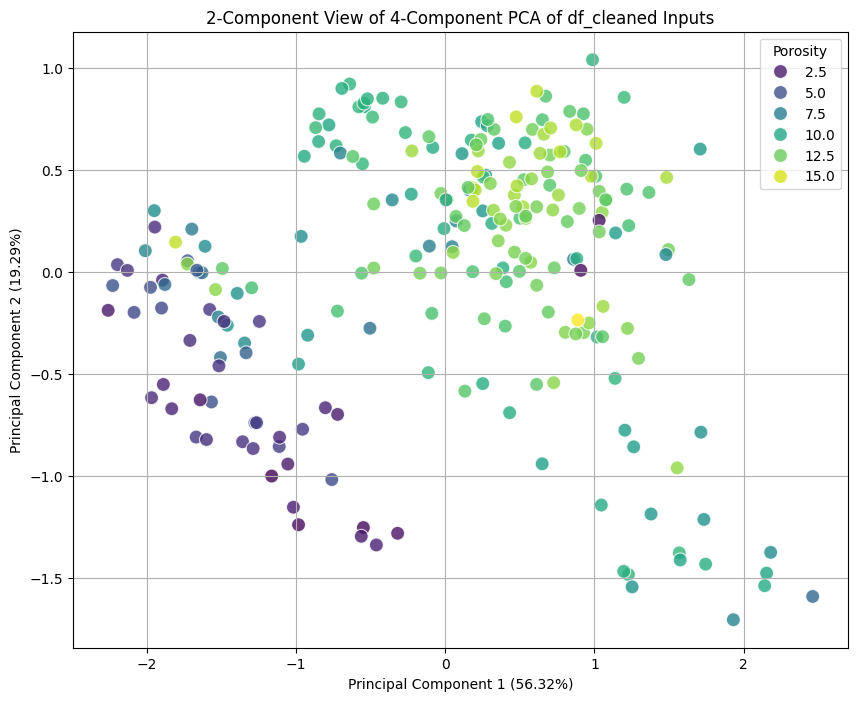

Explained variance ratio by PC1: 0.5632
Explained variance ratio by PC2: 0.1929
Explained variance ratio by PC3: 0.0811
Explained variance ratio by PC4: 0.0569
Total explained variance by 4 components: 0.8942


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# --- Code from cell hKgfTKPHFhwA to define X_scaled and y (for coloring) ---
# Make a copy of df_cleaned to avoid altering it for other cells if execution order is changed
df_cleaned_for_pca = df_cleaned.copy()

# Only drop 'Depth, ft' if it exists
if 'Depth, ft' in df_cleaned_for_pca.columns:
    df_cleaned_for_pca = df_cleaned_for_pca.drop(['Depth, ft'], axis=1)

X = df_cleaned_for_pca.drop(['Porosity, %'], axis=1)
y = df_cleaned_for_pca['Porosity, %'] # Define y locally for coloring the PCA plot

scaler = MinMaxScaler(feature_range=(-1, 1))
X_scaled = scaler.fit_transform(X)
# ------------------------------------------------------------------------

# Initialize PCA to reduce to 4 components
pca = PCA(n_components=4, random_state=42)

# Fit PCA to the scaled data and transform it
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for plotting the PCA results (using first two for 2D visualization)
pca_df = pd.DataFrame(data=X_pca, columns=[f'Principal Component {i+1}' for i in range(pca.n_components)])

# Add the target variable (porosity) to the PCA DataFrame for coloring
pca_df['Porosity'] = y.reset_index(drop=True)

# Plotting the first two PCA components
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Porosity', data=pca_df, palette='viridis', s=100, alpha=0.8)

plt.title('2-Component View of 4-Component PCA of df_cleaned Inputs')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.show()

print(f"Explained variance ratio by PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"Explained variance ratio by PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Explained variance ratio by PC3: {pca.explained_variance_ratio_[2]:.4f}")
print(f"Explained variance ratio by PC4: {pca.explained_variance_ratio_[3]:.4f}")
print(f"Total explained variance by 4 components: {pca.explained_variance_ratio_.sum():.4f}")

In [ ]:
import pandas as pd

# Create a DataFrame from the PCA components
pca_components_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

# Add the 'Porosity, %' column from the original target variable 'y'
# Ensure the index is reset to match if 'y' has a different index due to previous operations.
pca_components_df['Porosity, %'] = y.reset_index(drop=True)

# Define the output filename
output_filename = 'pca_components_with_porosity.csv'

# Save the DataFrame to a CSV file
pca_components_df.to_csv(output_filename, index=False)

print(f"PCA components with Porosity saved to {output_filename}")
display(pca_components_df.head())

PCA components with Porosity saved to pca_components_with_porosity.csv


,PC1,PC2,PC3,PC4,"Porosity, %"
0,0.05,0.13,-0.45,0.29,7.84
1,0.07,0.25,-0.33,0.62,8.15
2,-2.26,-0.19,-0.39,0.17,2.36
3,0.16,0.40,-0.02,0.60,7.62
4,-0.11,0.13,-0.51,0.32,7.67


,"Calcite, wt%","Dolomite, wt%","Quartz, wt%","Plagioclase, wt%","Pyrite, wt%","Illite / Smectite, wt%","Illite & Mica, wt%","Kaolinite, wt%","Chlorite, wt%","Total Clay, wt%","TOC, wt/wt","Porosity, %"
"Calcite, wt%",1.00,-0.02,-0.92,-0.35,-0.84,-0.94,-0.94,-0.51,-0.48,-0.93,-0.72,-0.55
"Dolomite, wt%",-0.02,1.00,-0.02,0.23,0.02,-0.03,-0.07,-0.16,-0.06,-0.10,0.05,0.17
"Quartz, wt%",-0.92,-0.02,1.00,0.26,0.72,0.83,0.84,0.40,0.29,0.80,0.64,0.47
"Plagioclase, wt%",-0.35,0.23,0.26,1.00,0.30,0.37,0.28,-0.36,-0.10,0.11,0.42,0.44
"Pyrite, wt%",-0.84,0.02,0.72,0.30,1.00,0.77,0.77,0.35,0.36,0.73,0.68,0.53
"Illite / Smectite, wt%",-0.94,-0.03,0.83,0.37,0.77,1.00,0.95,0.37,0.39,0.90,0.68,0.52
"Illite & Mica, wt%",-0.94,-0.07,0.84,0.28,0.77,0.95,1.00,0.46,0.45,0.93,0.64,0.48
"Kaolinite, wt%",-0.51,-0.16,0.40,-0.36,0.35,0.37,0.46,1.00,0.72,0.72,0.06,-0.08
"Chlorite, wt%",-0.48,-0.06,0.29,-0.10,0.36,0.39,0.45,0.72,1.00,0.66,0.15,-0.01
"Total Clay, wt%",-0.93,-0.10,0.80,0.11,0.73,0.90,0.93,0.72,0.66,1.00,0.53,0.35


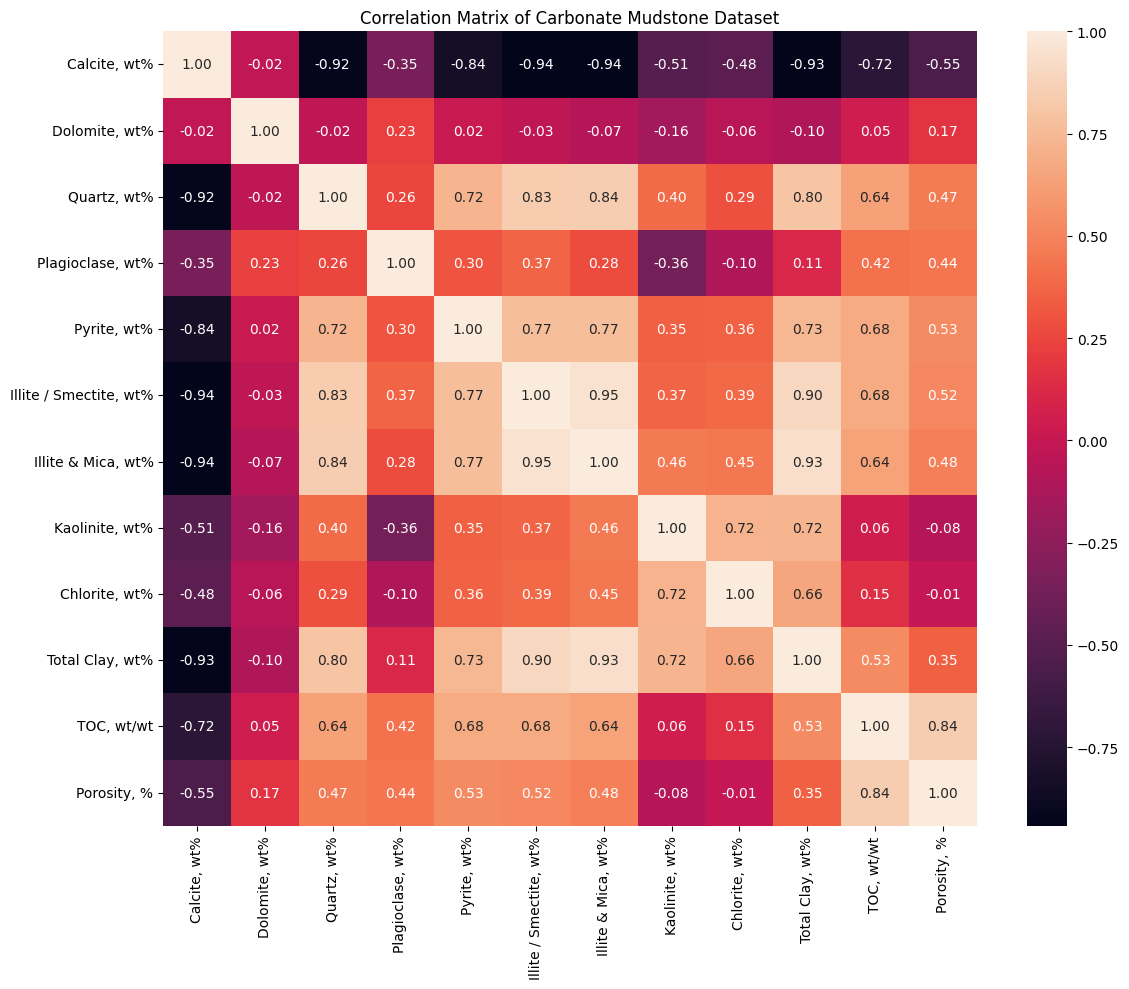

In [ ]:
corr_matrix = df_cleaned.corr()
display(corr_matrix)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title('Correlation Matrix of Carbonate Mudstone Dataset')
plt.tight_layout()
plt.show()

**Feature Importance**

Absolute Correlation of Features with Porosity (Descending Order):
TOC, wt/wt               0.84
Calcite, wt%             0.55
Pyrite, wt%              0.53
Illite / Smectite, wt%   0.52
Illite & Mica, wt%       0.48
Quartz, wt%              0.47
Plagioclase, wt%         0.44
Total Clay, wt%          0.35
Dolomite, wt%            0.17
Kaolinite, wt%           0.08
Chlorite, wt%            0.01
Name: Porosity, %, dtype: float64


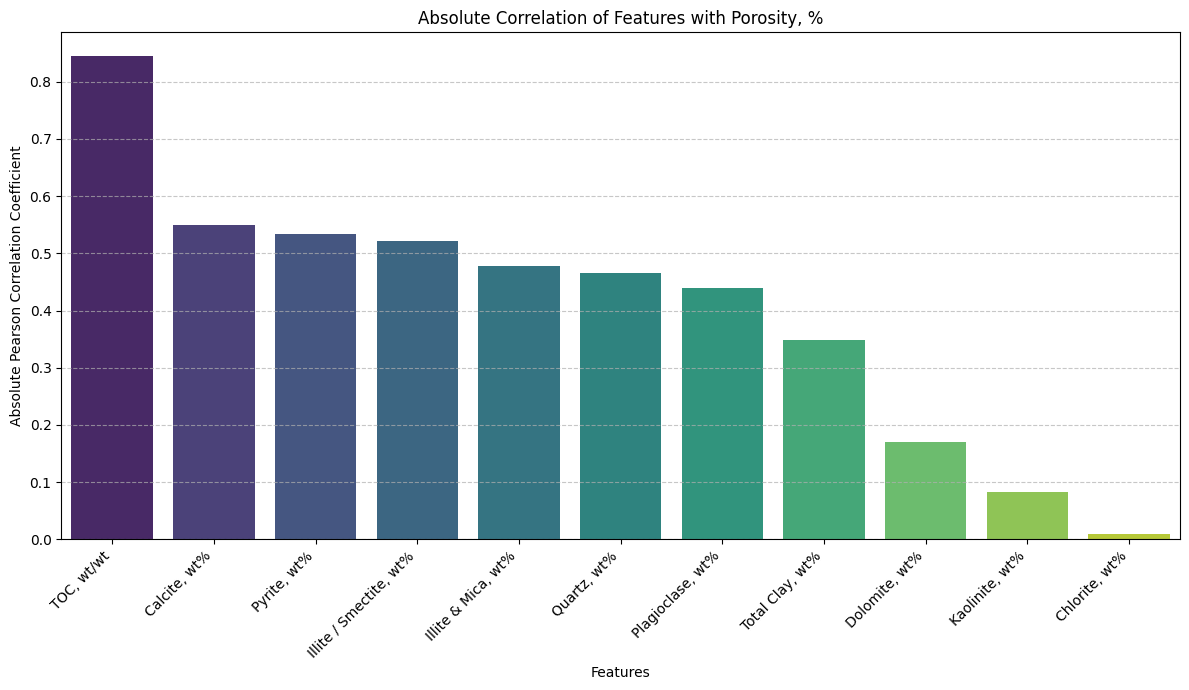

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the Pearson correlation matrix for the df_cleaned DataFrame
corr_matrix_full = df_cleaned.corr(method='pearson')

# Extract the correlation coefficients of all features with the 'Porosity, %' column
porosity_correlations = corr_matrix_full['Porosity, %']

# Take the absolute value of these correlation coefficients
absolute_porosity_correlations = porosity_correlations.abs()

# Exclude the 'Porosity, %' self-correlation
absolute_porosity_correlations = absolute_porosity_correlations.drop('Porosity, %')

# Store and sort these absolute correlation values in descending order
feature_importance_correlations = absolute_porosity_correlations.sort_values(ascending=False)

print("Absolute Correlation of Features with Porosity (Descending Order):")
print(feature_importance_correlations)

# Create a bar plot to visualize the absolute correlation coefficients
plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importance_correlations.index, y=feature_importance_correlations.values, palette='viridis')
plt.title('Absolute Correlation of Features with Porosity, %')
plt.xlabel('Features')
plt.ylabel('Absolute Pearson Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**LazyPredictor for whole the model**

In [ ]:
import numpy as np

# ----------------- CONFIG -----------------

N_CLUSTERS  = 2
N_NEIGHBORS = 10                  # for Spectral KNN affinity

OUT_CSV = "clusters.csv"
OUT_FIG = "pca_clusters.png"

# ------------------------------------------

def run_methods(X_scaled):
    labels = {}

    # 1) KMeans
    labels["kmeans"] = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=42).fit_predict(X_scaled)

    # 2) Gaussian Mixture
    gmm = GaussianMixture(n_components=N_CLUSTERS, random_state=42)
    gmm.fit(X_scaled)
    labels["gmm"] = gmm.predict(X_scaled)

    # 3) Agglomerative (Ward)
    labels["agglomerative"] = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage="ward").fit_predict(X_scaled)

    # 4) Spectral with KNN affinity
    labels["spectral_knn"] = SpectralClustering(
        n_clusters=N_CLUSTERS,
        affinity="nearest_neighbors",
        n_neighbors=N_NEIGHBORS,
        assign_labels="kmeans",
        random_state=42
    ).fit_predict(X_scaled)

    return labels

def print_metrics(X_scaled, labels_dict):
    print("\n=== Internal metrics (higher silhouette/Calinski better; lower Davies–Bouldin better) ===")
    for name, lab in labels_dict.items():
        uniq = np.unique(lab)
        if len(uniq) < 2:
            sil = np.nan
        else:
            sil = silhouette_score(X_scaled, lab)
        ch = calinski_harabasz_score(X_scaled, lab)
        db = davies_bouldin_score(X_scaled, lab)
        print(f"{name:>15s} | silhouette={sil:7.4f} | calinski={ch:9.1f} | davies_bouldin={db:7.4f}")

def save_output(df, labels_dict, out_csv):
    out = df.copy()
    for name, lab in labels_dict.items():
        out[f"{name}_cluster"] = lab
    out.to_csv(out_csv, index=False)
    print(f"\nSaved labels to: {out_csv}")

def plot_pca(X_scaled, labels_dict, out_fig):
    pca = PCA(n_components=2, random_state=42)
    X2 = pca.fit_transform(X_scaled)

    methods = list(labels_dict.keys())
    n = len(methods)
    rows, cols = (2, 2) if n <= 4 else (int(np.ceil(n/3)), 3)

    plt.figure(figsize=(5*cols, 4*rows))
    for i, name in enumerate(methods, 1):
        plt.subplot(rows, cols, i)
        lab = labels_dict[name]
        for u in np.unique(lab):
            mask = (lab == u)
            plt.scatter(X2[mask, 0], X2[mask, 1], s=20, alpha=0.9, label=f"cluster {u}")
        plt.title(name)
        plt.xlabel("PC1"); plt.ylabel("PC2")
        plt.legend(loc="best", fontsize=8)
        plt.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.savefig(out_fig, dpi=160)
    plt.close()
    print(f"Saved PCA plot to: {out_fig}")

def main():
    # df_cleaned, X, X_scaled are already prepared in previous cells.
    # We can directly use X_scaled for clustering and df_cleaned for saving output.
    labels_dict = run_methods(X_scaled)
    print_metrics(X_scaled, labels_dict)
    save_output(df_cleaned, labels_dict, OUT_CSV)
    plot_pca(X_scaled, labels_dict, OUT_FIG)

if __name__ == "__main__":
    main()


=== Internal metrics (higher silhouette/Calinski better; lower Davies–Bouldin better) ===
         kmeans | silhouette= 0.3770 | calinski=    172.6 | davies_bouldin= 1.0427
            gmm | silhouette= 0.3709 | calinski=    165.8 | davies_bouldin= 1.0559
  agglomerative | silhouette= 0.3884 | calinski=    157.8 | davies_bouldin= 0.9618
   spectral_knn | silhouette= 0.3895 | calinski=    157.4 | davies_bouldin= 0.9543

Saved labels to: clusters.csv
Saved PCA plot to: pca_clusters.png


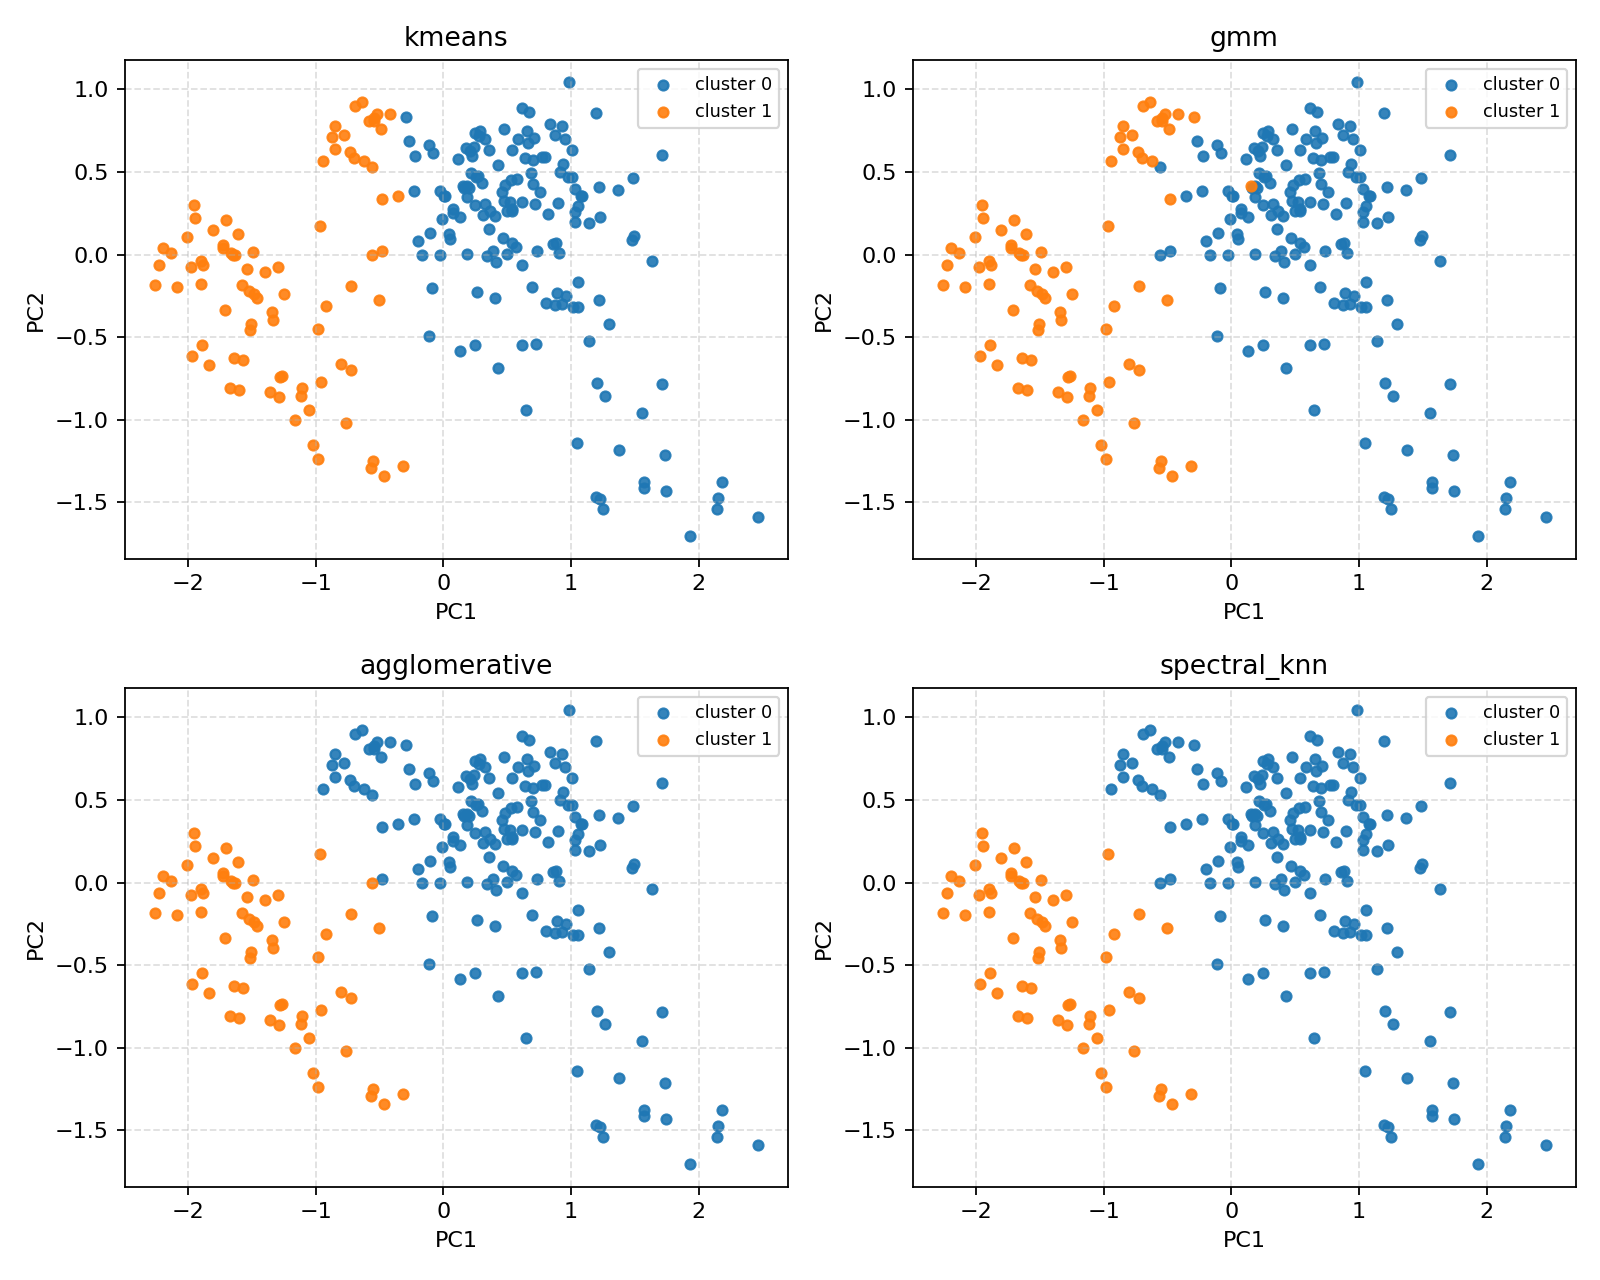

In [ ]:
from IPython.display import Image
Image('pca_clusters.png')

In [ ]:
df_with_clusters = pd.read_csv('clusters.csv')
print("Loaded df_with_clusters DataFrame with shape:", df_with_clusters.shape)
display(df_with_clusters.head())

Loaded df_with_clusters DataFrame with shape: (237, 16)


,"Calcite, wt%","Dolomite, wt%","Quartz, wt%","Plagioclase, wt%","Pyrite, wt%","Illite / Smectite, wt%","Illite & Mica, wt%","Kaolinite, wt%","Chlorite, wt%","Total Clay, wt%","TOC, wt/wt","Porosity, %",kmeans_cluster,gmm_cluster,agglomerative_cluster,spectral_knn_cluster
0,53.38,0.00,19.63,2.32,2.80,8.87,7.82,0.00,0.81,17.56,3.00,7.84,0,0,0,0
1,52.28,0.00,19.34,3.60,2.82,8.62,8.27,0.00,0.89,17.83,2.57,8.15,0,0,0,0
2,89.37,0.00,4.48,0.70,0.90,1.85,2.44,0.00,0.00,4.29,0.34,2.36,1,1,1,1
3,50.50,0.69,16.57,3.63,2.94,11.55,10.41,0.00,0.00,22.00,1.77,7.62,0,0,0,0
4,54.13,0.00,19.18,2.06,3.52,8.90,8.42,0.00,0.00,17.36,1.93,7.67,0,0,0,0


In [ ]:
import os

# Re-load df_from_clusters_csv to ensure new_data_df is freshly prepared
df_from_clusters_csv = pd.read_csv('clusters.csv')

# Create new_data_df_cleaned from df_with_clusters by dropping the other cluster columns
# and assuming 'Porosity, %' should remain in the grouped CSVs as features for regression.
columns_to_drop_from_df = ['gmm_cluster','agglomerative_cluster','kmeans_cluster']
new_data_df_cleaned = df_with_clusters.drop(columns=columns_to_drop_from_df)


display(new_data_df_cleaned)

# Group by predicted_spectral_knn_cluster and save each group to a separate CSV file
unique_predicted_clusters = new_data_df_cleaned['spectral_knn_cluster'].unique()
for cluster_id in unique_predicted_clusters:
    # Filter data for the current cluster
    cluster_data = new_data_df_cleaned[new_data_df_cleaned['spectral_knn_cluster'] == cluster_id].copy()

    # Drop the 'spectral_knn_cluster' column before saving, as it's used for grouping but might not be desired in the output file itself
    cluster_data_to_save = cluster_data.drop('spectral_knn_cluster', axis=1)

    # Create filename
    filename = f'new_data_cluster_{int(cluster_id)}.csv'

    # Save to CSV
    cluster_data_to_save.to_csv(filename, index=False)
    print(f"Saved cluster {int(cluster_id)} data to {filename}")

print("\nClassification and saving of new data to CSVs complete.")

,"Calcite, wt%","Dolomite, wt%","Quartz, wt%","Plagioclase, wt%","Pyrite, wt%","Illite / Smectite, wt%","Illite & Mica, wt%","Kaolinite, wt%","Chlorite, wt%","Total Clay, wt%","TOC, wt/wt","Porosity, %",spectral_knn_cluster
0,53.38,0.00,19.63,2.32,2.80,8.87,7.82,0.00,0.81,17.56,3.00,7.84,0
1,52.28,0.00,19.34,3.60,2.82,8.62,8.27,0.00,0.89,17.83,2.57,8.15,0
2,89.37,0.00,4.48,0.70,0.90,1.85,2.44,0.00,0.00,4.29,0.34,2.36,1
3,50.50,0.69,16.57,3.63,2.94,11.55,10.41,0.00,0.00,22.00,1.77,7.62,0
4,54.13,0.00,19.18,2.06,3.52,8.90,8.42,0.00,0.00,17.36,1.93,7.67,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,75.11,0.00,8.46,0.00,0.80,6.04,5.10,3.14,0.94,15.23,0.47,3.38,1
233,69.88,0.00,10.08,0.00,1.30,5.73,5.71,4.80,1.73,17.97,0.16,1.83,1
234,62.23,0.00,11.89,0.00,2.70,7.22,6.34,5.27,1.75,20.58,0.11,2.46,1
235,58.25,0.00,13.07,0.00,6.18,5.42,5.27,6.27,1.58,18.56,0.23,2.14,1


Saved cluster 0 data to new_data_cluster_0.csv
Saved cluster 1 data to new_data_cluster_1.csv

Classification and saving of new data to CSVs complete.


**New data, cluster 0**

In [ ]:
df_clusters_0 = pd.read_csv('/content/new_data_cluster_0.csv')
X0 = df_clusters_0.drop(['Porosity, %'], axis=1)
y0 = df_clusters_0['Porosity, %']

display(X0.head())
display(y0.head())
scaler = MinMaxScaler(feature_range=(-1, 1))
X0_scaled = scaler.fit_transform(X0)

# Split the data into training and testing sets (70/30 split)
X0_train, X0_test, y0_train, y0_test = train_test_split(X0_scaled,y0 , test_size=0.15, random_state=42)

# Initialize LazyRegressor
reg_0 = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)

# Fit the models and get predictions
models_0, predictions_0 = reg_0.fit(X0_train, X0_test, y0_train, y0_test)

# Display all columns in the model performance results
print("Available Columns in Model Performance Results:")
print(models_0.columns)

# Display selected performance metrics (use available columns from the printed list)
selected_columns_0 = ['R-Squared', 'Adjusted R-Squared', 'RMSE']
print("\nModel Performance Results:")
print(models_0[selected_columns_0])

# BEST DATA: CA data + H2 conc (50) - No Pressure

,"Calcite, wt%","Dolomite, wt%","Quartz, wt%","Plagioclase, wt%","Pyrite, wt%","Illite / Smectite, wt%","Illite & Mica, wt%","Kaolinite, wt%","Chlorite, wt%","Total Clay, wt%","TOC, wt/wt"
0,53.38,0.00,19.63,2.32,2.80,8.87,7.82,0.00,0.81,17.56,3.00
1,52.28,0.00,19.34,3.60,2.82,8.62,8.27,0.00,0.89,17.83,2.57
2,50.50,0.69,16.57,3.63,2.94,11.55,10.41,0.00,0.00,22.00,1.77
3,54.13,0.00,19.18,2.06,3.52,8.90,8.42,0.00,0.00,17.36,1.93
4,50.06,0.58,17.60,3.31,4.86,9.85,9.39,0.00,0.00,19.30,2.54


,"Porosity, %"
0,7.84
1,8.15
2,7.62
3,7.67
4,9.09


  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000172 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 484
[LightGBM] [Info] Number of data points in the train set: 147, number of used features: 11
[LightGBM] [Info] Start training from score 11.580781
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

Feature Importance for cluster 0

Feature Importance of cluster 1

Absolute Correlation of Features with Porosity (Descending Order):
TOC, wt/wt               0.74
Chlorite, wt%            0.49
Plagioclase, wt%         0.47
Kaolinite, wt%           0.41
Total Clay, wt%          0.31
Illite & Mica, wt%       0.18
Illite / Smectite, wt%   0.14
Pyrite, wt%              0.13
Calcite, wt%             0.11
Quartz, wt%              0.10
Dolomite, wt%            0.08
Name: Porosity, %, dtype: float64


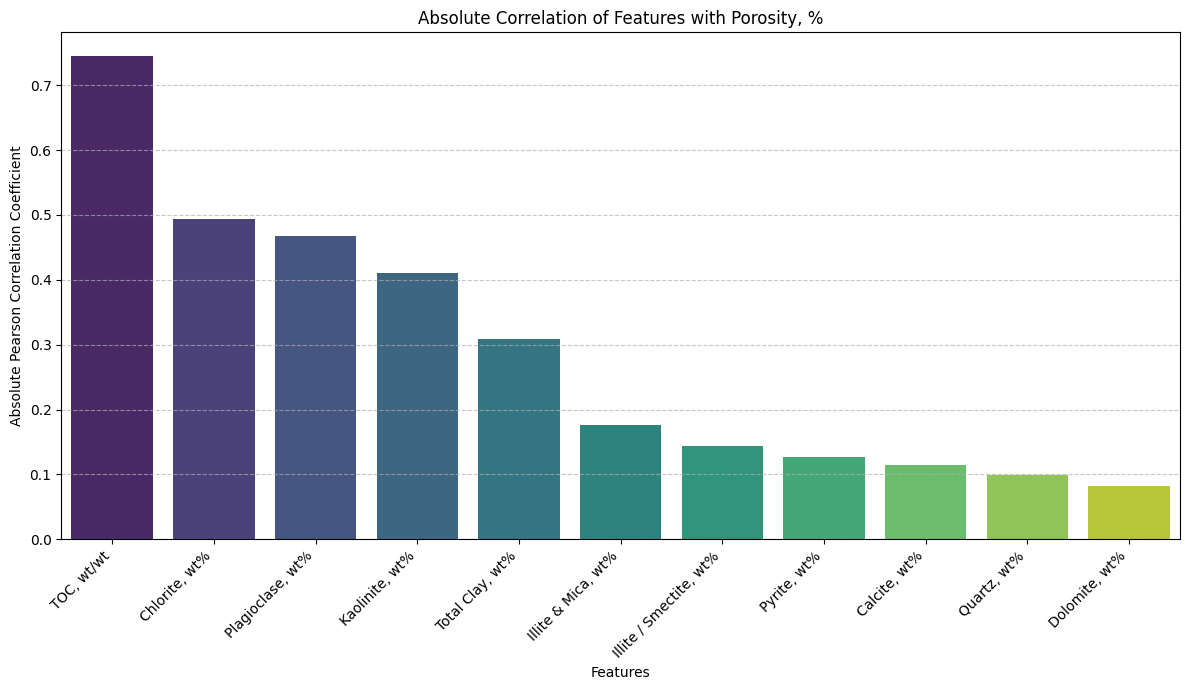

In [ ]:
corr_matrix_full_1 = df_clusters_1.corr(method='pearson')

# Extract the correlation coefficients of all features with the 'Porosity, %' column
porosity_correlations_1 = corr_matrix_full_1['Porosity, %']

# Take the absolute value of these correlation coefficients
absolute_porosity_correlations_1 = porosity_correlations_1.abs()

# Exclude the 'Porosity, %' self-correlation
absolute_porosity_correlations_1 = absolute_porosity_correlations_1.drop('Porosity, %')

# Store and sort these absolute correlation values in descending order
feature_importance_correlations_1 = absolute_porosity_correlations_1.sort_values(ascending=False)

print("Absolute Correlation of Features with Porosity (Descending Order):")
print(feature_importance_correlations_1)

# Create a bar plot to visualize the absolute correlation coefficients
plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importance_correlations_1.index, y=feature_importance_correlations_1.values, palette='viridis')
plt.title('Absolute Correlation of Features with Porosity, %')
plt.xlabel('Features')
plt.ylabel('Absolute Pearson Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
corr_matrix_0 = df_clusters_0.corr()
corr_matrix_1 = df_clusters_1.corr()


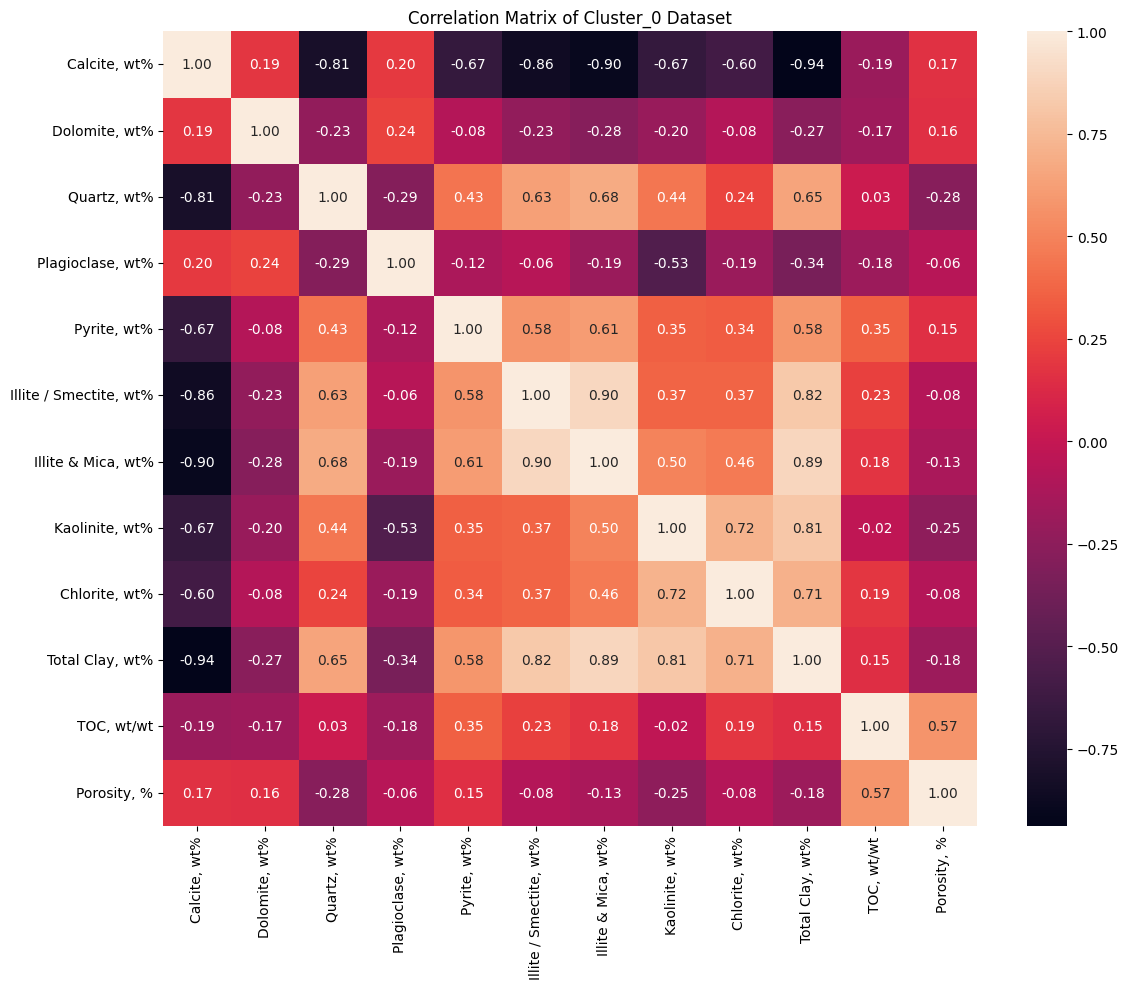

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_0, annot=True, fmt=".2f")
plt.title('Correlation Matrix of Cluster_0 Dataset')
plt.tight_layout()
plt.show()

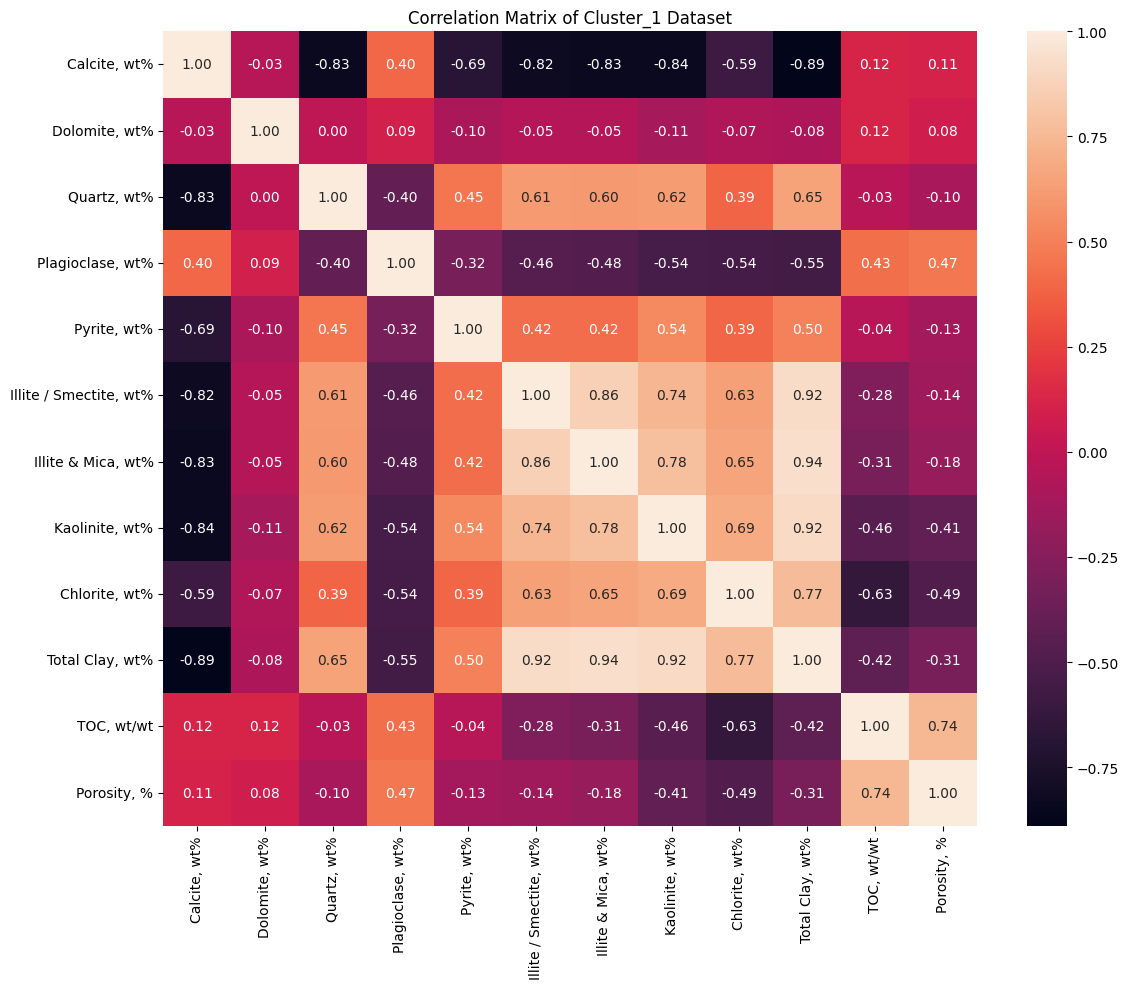

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_1, annot=True, fmt=".2f")
plt.title('Correlation Matrix of Cluster_1 Dataset')
plt.tight_layout()
plt.show()

Absolute Correlation of Features with Porosity (Descending Order):
TOC, wt/wt               0.57
Quartz, wt%              0.28
Kaolinite, wt%           0.25
Total Clay, wt%          0.18
Calcite, wt%             0.17
Dolomite, wt%            0.16
Pyrite, wt%              0.15
Illite & Mica, wt%       0.13
Chlorite, wt%            0.08
Illite / Smectite, wt%   0.08
Plagioclase, wt%         0.06
Name: Porosity, %, dtype: float64


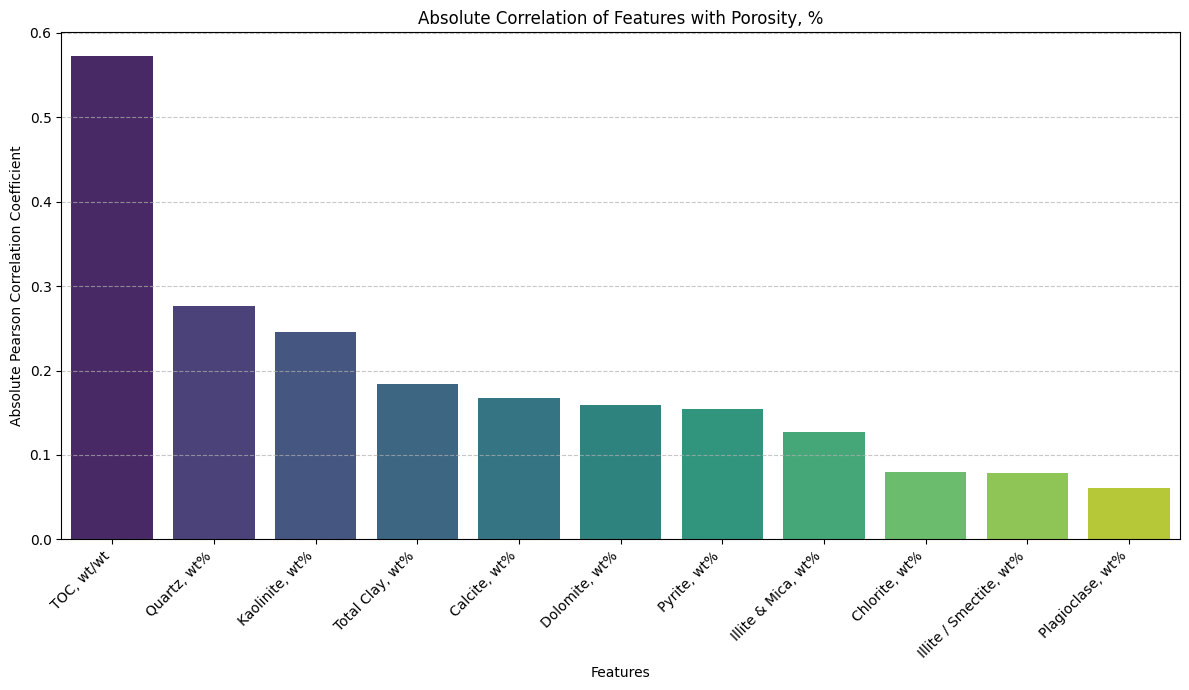

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the Pearson correlation matrix for the df_cleaned DataFrame
corr_matrix_full = df_clusters_0.corr(method='pearson')

# Extract the correlation coefficients of all features with the 'Porosity, %' column
porosity_correlations = corr_matrix_full['Porosity, %']

# Take the absolute value of these correlation coefficients
absolute_porosity_correlations = porosity_correlations.abs()

# Exclude the 'Porosity, %' self-correlation
absolute_porosity_correlations = absolute_porosity_correlations.drop('Porosity, %')

# Store and sort these absolute correlation values in descending order
feature_importance_correlations = absolute_porosity_correlations.sort_values(ascending=False)

print("Absolute Correlation of Features with Porosity (Descending Order):")
print(feature_importance_correlations)

# Create a bar plot to visualize the absolute correlation coefficients
plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importance_correlations.index, y=feature_importance_correlations.values, palette='viridis')
plt.title('Absolute Correlation of Features with Porosity, %')
plt.xlabel('Features')
plt.ylabel('Absolute Pearson Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Absolute Correlation of Features with Porosity (Descending Order):
TOC, wt/wt               0.74
Chlorite, wt%            0.49
Plagioclase, wt%         0.47
Kaolinite, wt%           0.41
Total Clay, wt%          0.31
Illite & Mica, wt%       0.18
Illite / Smectite, wt%   0.14
Pyrite, wt%              0.13
Calcite, wt%             0.11
Quartz, wt%              0.10
Dolomite, wt%            0.08
Name: Porosity, %, dtype: float64


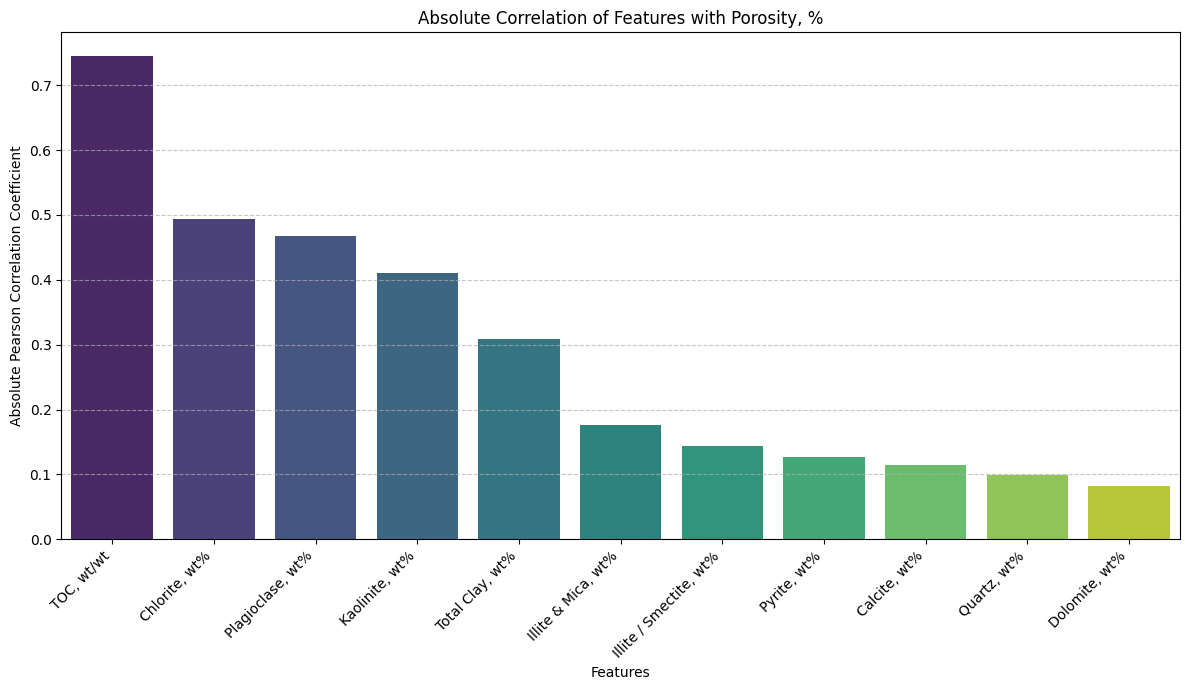

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the Pearson correlation matrix for the df_cleaned DataFrame
corr_matrix_full = df_clusters_1.corr(method='pearson')

# Extract the correlation coefficients of all features with the 'Porosity, %' column
porosity_correlations = corr_matrix_full['Porosity, %']

# Take the absolute value of these correlation coefficients
absolute_porosity_correlations = porosity_correlations.abs()

# Exclude the 'Porosity, %' self-correlation
absolute_porosity_correlations = absolute_porosity_correlations.drop('Porosity, %')

# Store and sort these absolute correlation values in descending order
feature_importance_correlations = absolute_porosity_correlations.sort_values(ascending=False)

print("Absolute Correlation of Features with Porosity (Descending Order):")
print(feature_importance_correlations)

# Create a bar plot to visualize the absolute correlation coefficients
plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importance_correlations.index, y=feature_importance_correlations.values, palette='viridis')
plt.title('Absolute Correlation of Features with Porosity, %')
plt.xlabel('Features')
plt.ylabel('Absolute Pearson Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**XGBoost Model**

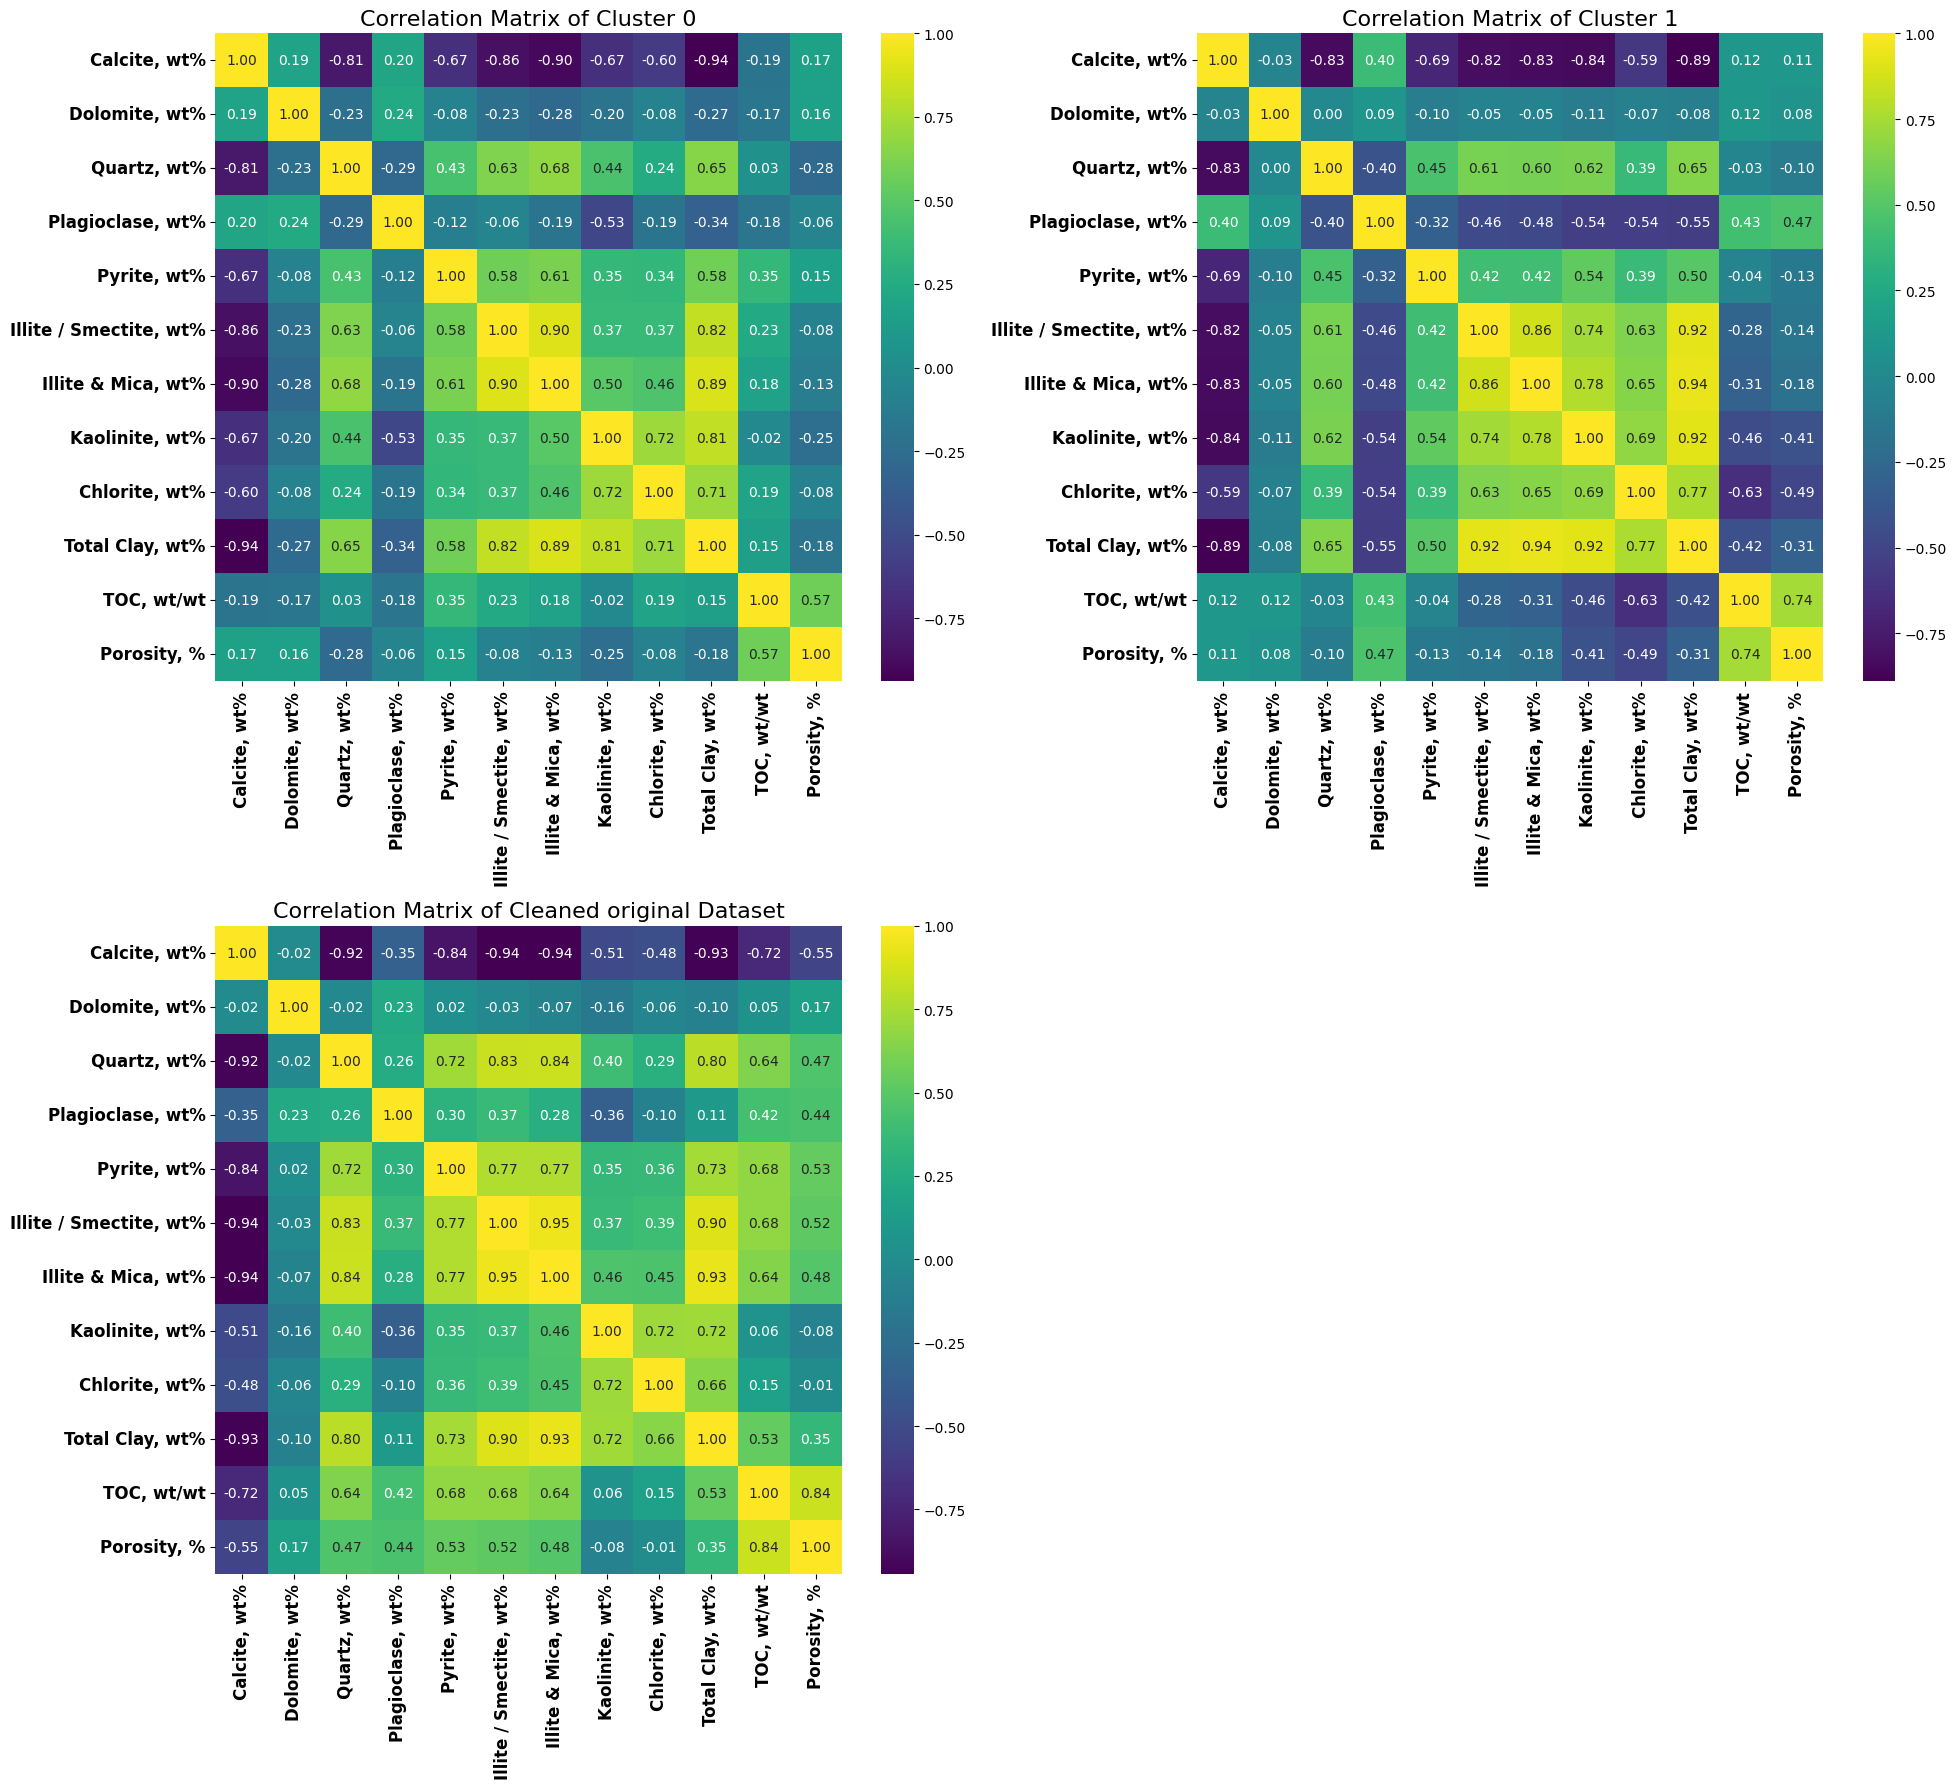

In [ ]:
# Modified cell xZsJyReD_9V6
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming corr_matrix, corr_matrix_0, and corr_matrix_1 are already defined from previous cells.
# If not, they would need to be re-calculated or loaded here.
# For robustness, ensuring they are available:
# These would be the actual lines if not already loaded globally by the notebook state.
# corr_matrix = df_cleaned.corr()
# corr_matrix_0 = df_clusters_0.corr()
# corr_matrix_1 = df_clusters_1.corr()

# Create a figure with a 2x2 grid of subplots
fig = plt.figure(figsize=(20, 18)) # Adjusted figure size for better readability

# Subplot for the original correlation matrix (spanning two columns on the first row)
ax0 = plt.subplot(2, 2, 3) # Spans column 1 and 2 of the first row
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='viridis', ax=ax0)
ax0.set_title('Correlation Matrix of Cleaned original Dataset', fontsize=16)
ax0.tick_params(axis='x', labelsize=12) # Increased font size for x-axis labels
ax0.tick_params(axis='y', labelsize=12) # Increased font size for y-axis labels
for tick_label in ax0.get_xticklabels():
    tick_label.set_fontweight('bold')
for tick_label in ax0.get_yticklabels():
    tick_label.set_fontweight('bold')

# Subplot for Cluster 0 correlation matrix
ax1 = plt.subplot(2, 2, 1) # Second row, first column
sns.heatmap(corr_matrix_0, annot=True, fmt=".2f", cmap='viridis', ax=ax1)
ax1.set_title('Correlation Matrix of Cluster 0', fontsize=16)
ax1.tick_params(axis='x', labelsize=12) # Increased font size for x-axis labels
ax1.tick_params(axis='y', labelsize=12) # Increased font size for y-axis labels
for tick_label in ax1.get_xticklabels():
    tick_label.set_fontweight('bold')
for tick_label in ax1.get_yticklabels():
    tick_label.set_fontweight('bold')

# Subplot for Cluster 1 correlation matrix
ax2 = plt.subplot(2, 2, 2) # Second row, second column
sns.heatmap(corr_matrix_1, annot=True, fmt=".2f", cmap='viridis', ax=ax2)
ax2.set_title('Correlation Matrix of Cluster 1', fontsize=16)
ax2.tick_params(axis='x', labelsize=12) # Increased font size for x-axis labels
ax2.tick_params(axis='y', labelsize=12) # Increased font size for y-axis labels
for tick_label in ax2.get_xticklabels():
    tick_label.set_fontweight('bold')
for tick_label in ax2.get_yticklabels():
    tick_label.set_fontweight('bold')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.savefig('correlation_matrices_high_res.png', dpi=600) # Save with higher DPI
plt.show()